# Laboratorio de Redes Neuronales Convolucionales (CNN)

Observación: El código utilizado aquí esta basado mayoritariamente en el presentado en el libro *Hands-On Machine Learning with Scikit-Learn Keras & TensorFlow*

* Se cargan las librerías

In [1]:
import sys
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

* Se carga la configuración para la visualización

In [2]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

* Se recomienda usar GPU porque los modelos de CNN toman mucho tiempo en entrenar.

In [3]:
IS_COLAB = "google.colab" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")

## Implementación de capas convolucionales con Keras

* Se descarga un conjunto de datos con dos imágenes: una es una torres china y la otra es una flor

In [4]:
from sklearn.datasets import load_sample_images

dataset = load_sample_images()
print(len(dataset["images"]))

2


* Características de la primera imagen.

In [5]:
first_img_data = dataset["images"][0]
first_img_data.shape

(427, 640, 3)

* Se visualiza la primera imagen.

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

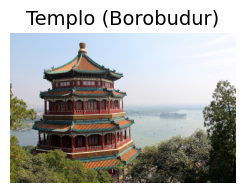

In [6]:
plt.subplot(1, 2, 1)
plt.imshow(first_img_data)
plt.title("Templo (Borobudur)")
plt.axis('off')

* Características de la segunda imagen.

In [7]:
second_img_data = dataset["images"][1]
second_img_data.shape

(427, 640, 3)

* Se visualiza la segunda imagen.

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

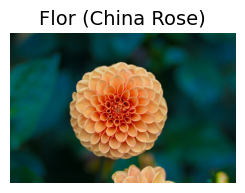

In [8]:
plt.subplot(1, 2, 2)
plt.imshow(second_img_data)
plt.title("Flor (China Rose)")
plt.axis('off')

* Se carga las dos imágenes de muestra.
* Se escala los valores de píxel al rango 0-1.
* Se hace un recorte centrado para obtener imágenes pequeñas de 70×120.

In [9]:
images = dataset["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

Se tienen un vector de 4D, esto es:
* Son dos imágenes.
* La imágen es de 70 X 120 píxeles
* Cada píxel tiene un vector de dimensión 3 que corresponde a los valores de los colores RGB.

In [10]:
images.shape

TensorShape([2, 70, 120, 3])

* Se crea un capa convolucional que recibe como entrada las dos imágenes.
* La capa tiene 32 filtros.
* Cada filtro (kernel) tiene de tamaño 7 X 7.
* Por defecto la opción predeterminada `padding="valid"`, que significa que no hay ningún relleno de ceros.
* La nueva capa de denomina mapa de característica.

In [11]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7) # padding="valid"
fmaps = conv_layer(images)

* Se muestra la configuración de la capa resultante

In [12]:
fmaps.shape

TensorShape([2, 64, 114, 32])

* Se muestra los mapas caracteríticos de cada imagen

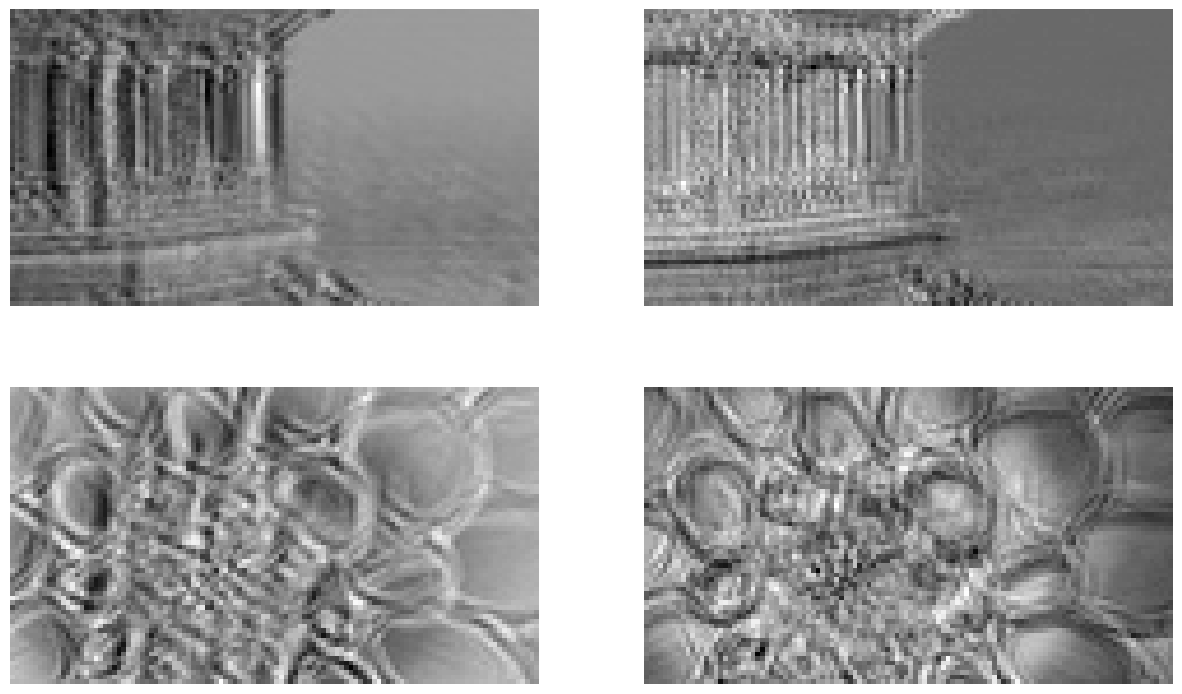

In [13]:
plt.figure(figsize=(15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

* Con `padding="same"`, entonces las entradas se rellenan con suficientes ceros por todos los lados
* El mapa de característica de salida tiene el mismo tamaño que la entrada.

In [14]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same")
fmaps = conv_layer(images)

:* Se muestra la dimensión del mapa de característica.

In [15]:
fmaps.shape

TensorShape([2, 70, 120, 32])

Ejemplo adicional:
* Misma configuración anterior.
* Ejemplo con stride = 2.

In [16]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same",
                                    strides=2)
fmaps = conv_layer(images)
fmaps.shape

TensorShape([2, 35, 60, 32])

* Se ilustra el `padding="valid"` y `padding="same"`
* Se usa `padding=1`

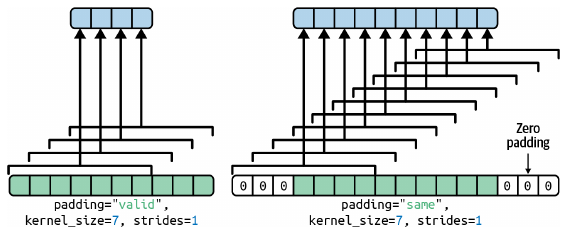

* Se ilustra el `padding="valid"` y `padding="same"`
* Se usa `padding=2`

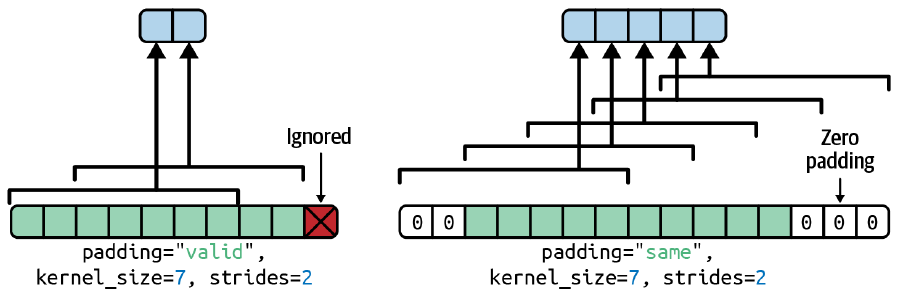

* La nueva capa tiene los pesos y el sesgo.
* Se obtiene los valores del kernel y el sesgo.
* El kernel tiene cuatro dimensiones  [kernel_height, kernel_width, input_channels,
output_channels]

In [17]:
kernels, biases = conv_layer.get_weights()
kernels.shape

(7, 7, 3, 32)

* Se muestra los valores del sesgo.
* El sesgo es un vector (1D).


In [18]:
biases.shape

(32,)

## Capas de agrupamiento (Pooling Layers)
* Se define la dimensión del agrupamiento.
* Se define si se aplica la función "max pooling" o "average pooling"

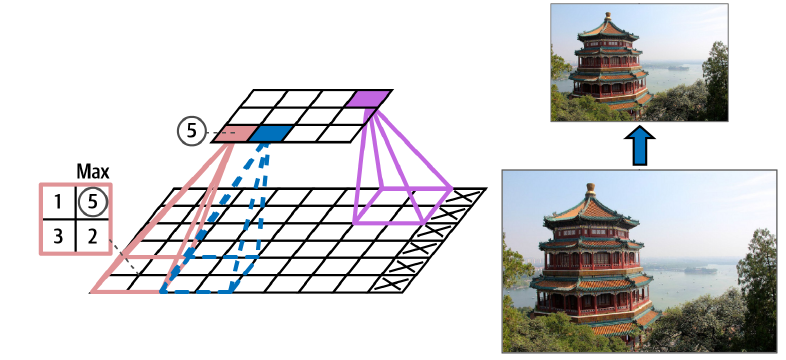


* Se crea un Pool de 2 X 2 usando max pooling.

In [19]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)

* Ilustración de Max Pooling en una CNN
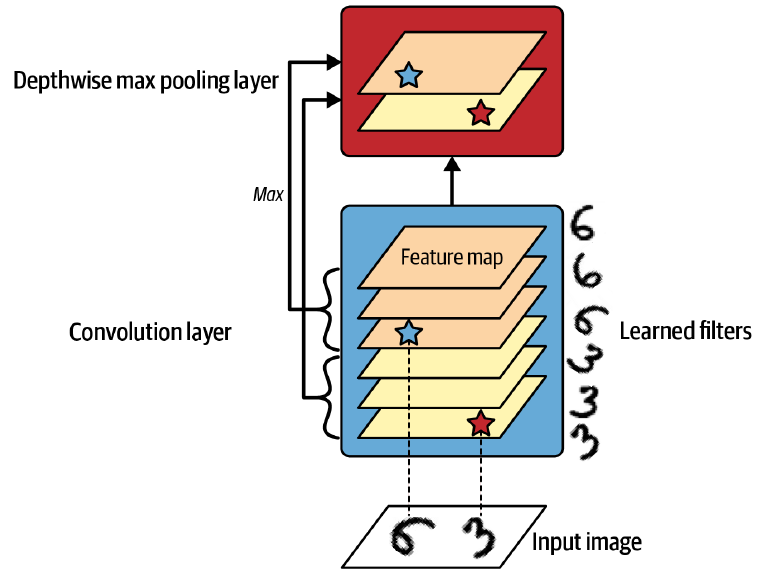

In [20]:
output = max_pool(images)

* Se muestra la capa de agrupamiento de la primera imagen con stride = 2.


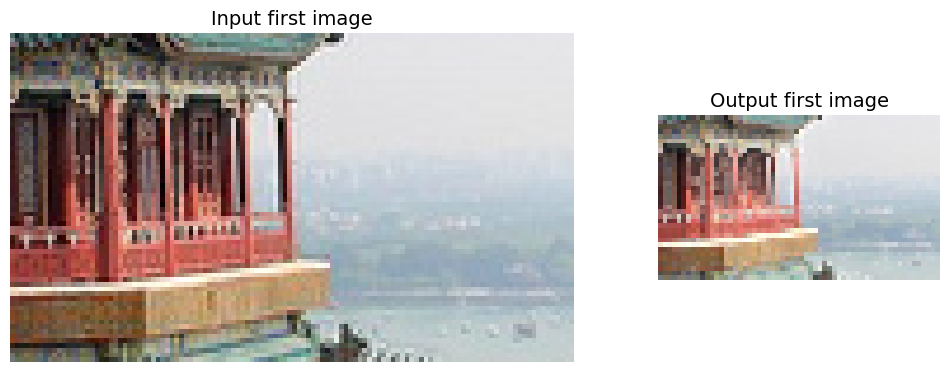

In [21]:
import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input first image")
ax1.imshow(images[0])  # plot the 1st image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output first image")
ax2.imshow(output[0])  # plot the output for the 1st image
ax2.axis("off")
plt.show()

* Se muestra la capa de agrupamiento de la segunda imagen con stride = 2.


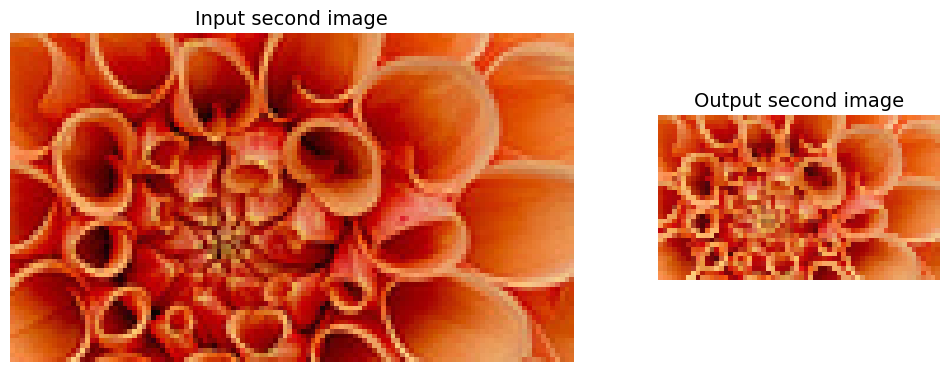

In [22]:
import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input second image")
ax1.imshow(images[1])  # plot the 2nd image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output second image")
ax2.imshow(output[1])  # plot the output for the 2nd image
ax2.axis("off")
plt.show()

In [23]:
class DepthPool(tf.keras.layers.Layer):
  def __init__(self, pool_size=2, **kwargs):
    super().__init__(**kwargs)
    self.pool_size = pool_size
  def call(self, inputs):
    shape = tf.shape(inputs) # shape[-1] is the number of channels
    groups = shape[-1] // self.pool_size # number of channel groups
    new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
    return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

* Usando agrupamiento promedio con Keras

In [24]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

* Si aplica a las imágenes obenmos los valores promedios de Red, Green y Blue.

In [25]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.643388  , 0.59718215, 0.5825038 ],
       [0.7630747 , 0.26010972, 0.10848834]], dtype=float32)>

## Arquitecturas de la CNN

* Arquitectura típica de una CNN
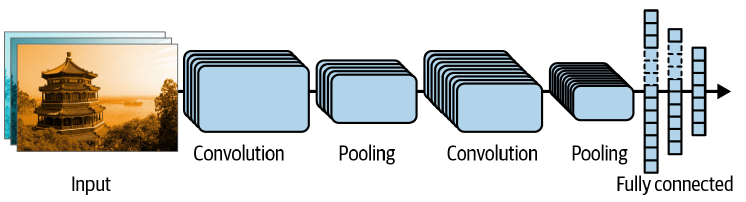

* Se carga el conjunto de datos Fashion MNIST

In [26]:
mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


* Se crea una CNN para hacer clasificación del conjunto de datos Fashion MNIST.

In [27]:
from functools import partial

DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same", activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
  DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
  tf.keras.layers.MaxPool2D(),
  DefaultConv2D(filters=128),
  DefaultConv2D(filters=128),
  tf.keras.layers.MaxPool2D(),
  DefaultConv2D(filters=256),
  DefaultConv2D(filters=256),
  tf.keras.layers.MaxPool2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(units=128, activation="relu",
  kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=64, activation="relu",
  kernel_initializer="he_normal"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* Se compila el modelo.
* Se hace las predicciones en el conjunto de datos.

In [28]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]  # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.7410 - loss: 0.7411 - val_accuracy: 0.8672 - val_loss: 0.3627
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8575 - loss: 0.4261 - val_accuracy: 0.8930 - val_loss: 0.2966
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8810 - loss: 0.3534 - val_accuracy: 0.8910 - val_loss: 0.2929
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8947 - loss: 0.3119 - val_accuracy: 0.9060 - val_loss: 0.2645
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9021 - loss: 0.2901 - val_accuracy: 0.9068 - val_loss: 0.2644
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9091 - loss: 0.2684 - val_accuracy: 0.9036 - val_loss: 0.2805
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9138 - loss: 0.2552 - val_accuracy: 0.9090 - val_loss: 0.2765
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9176 - loss: 

### Le-Net 5
* Propuesta por Lecun et al. en 1998.
* Es una de las primeras CNN que compite con el estado del arte en la época.
* Ampliamente usada en la detección de dígitos en los bancos.

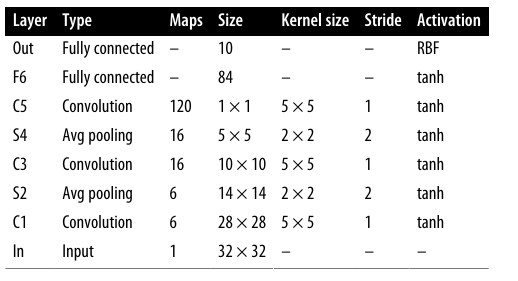

* Ilustración de la arquitectura de Len-Net-5.
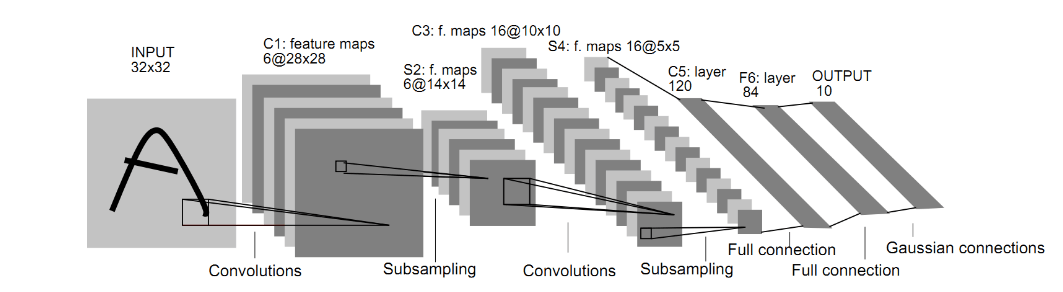

## AlexNet

* Ganó el ImageNet Large Scale Visual Recognition Challenge (ILSVRC) del 2012 por largo margen.
* Su tasa de error fue de 17%.
* Similar a LeNet-5 para más larga y profunda.




* Arquitectura de AlexNet


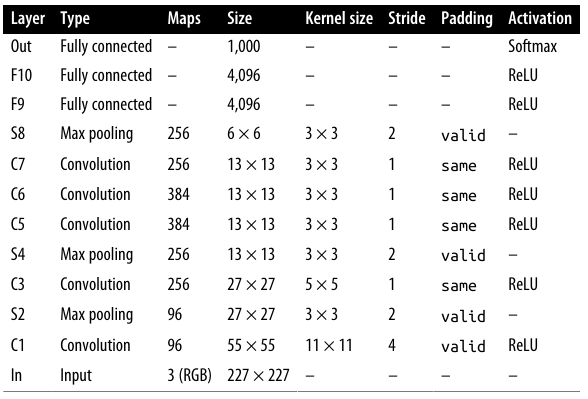

## ResNet

* Ganó el ILSVRC el 2015 con una tasa de error de 3.6%.
* Es CNN de 152 capas, con variantes de 34, 50 y 101 capas.
* Se *skip connections* donde una la salida de una capa alimenta otra varios niveles abajo.
* Se crea las redes residuales: Se quiere aprender $h(x)$, si agregas a la salida $x$ (*skip connection*), entonces la red tiene que aprender $h(x) - x$.

* Ilustración de una red residual

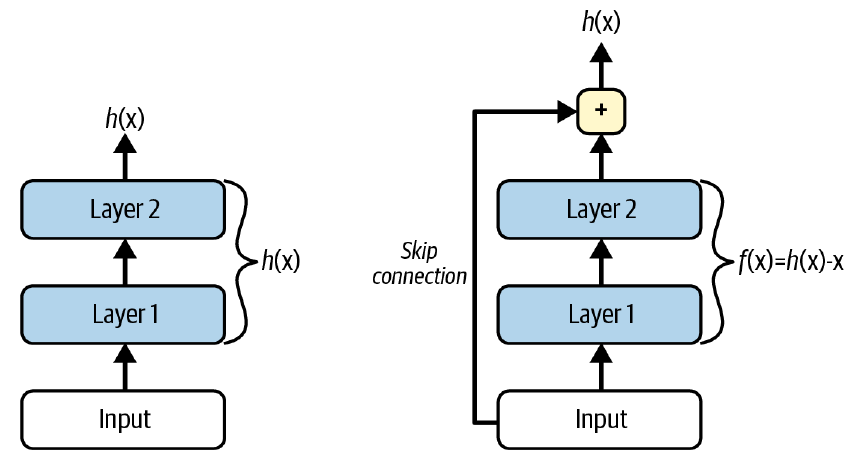

* Regular deep neural network (izquierda) y deep residual network (derecha)

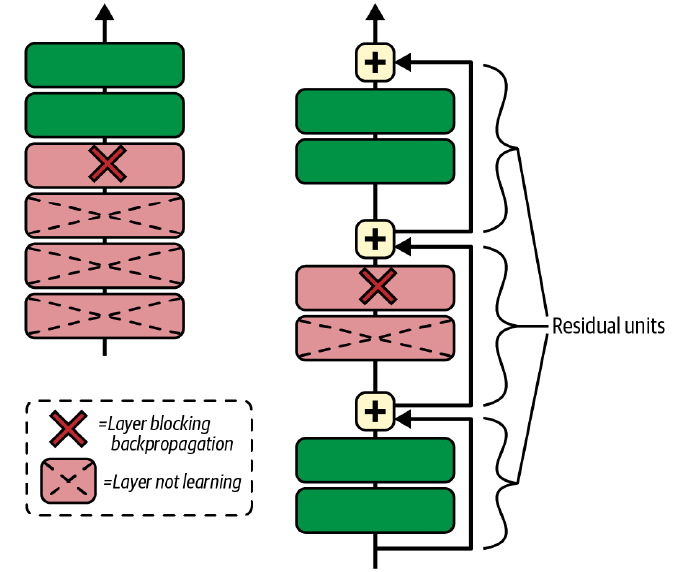

* Arquitectura ResNet

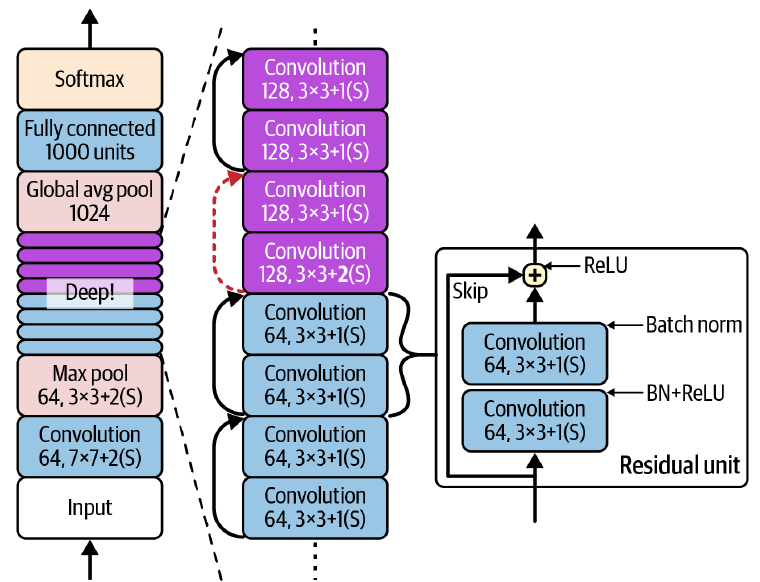

### Implementación de una CNN ResNet-34 utilizando Keras

In [29]:
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False)

class ResidualUnit(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [30]:
model = tf.keras.Sequential([
    DefaultConv2D(64, kernel_size=7, strides=2, input_shape=[224, 224, 3]),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

## Modelos Pre-Entrenados

* En lugar de crear un modelo desde cero, se puede usar un modelo preentrenado.
* Lista de modelos preentrenados [https://keras.io/api/applications](https://keras.io/api/applications)
* La elección del modelo va a depender del tipo de aplicación a resolver.

### Lista parcial de modelos pre entrenados disponibles en Keras

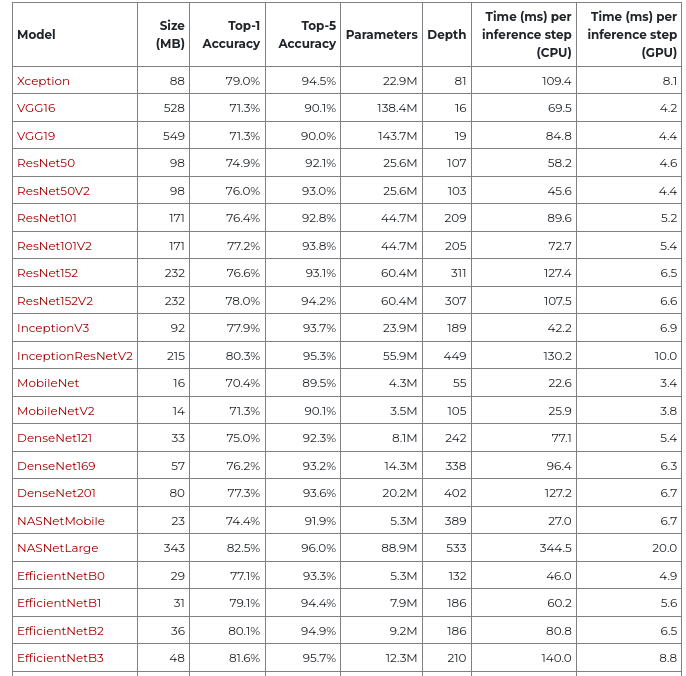

## Usando modelos pre entrendos de Keras

* La idea es usar modelos pre entrenados para resolver problemas en lugar de crear una modelo desde cero.

### Ejemplo de uso de un modelo pre entrenado

* Se carga el modelo ResNet-50

In [31]:
model = tf.keras.applications.ResNet50(weights="imagenet")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


* Se carga el conjunto de datos de imagenes

In [32]:
K = tf.keras.backend
images = K.constant(load_sample_images()["images"])
images_resized = tf.keras.layers.Resizing(height=224, width=224,
                                          crop_to_aspect_ratio=True)(images)

* Se preprocesa la imagen

In [33]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

* Podemos usar el modelo para hacer predicciones.

In [34]:
Y_proba = model.predict(inputs)
Y_proba.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


(2, 1000)

* Se tiene dos imagenes y 1000 posibles clases de imágenes:
* Se muestra las principales predicciones del modelo

In [35]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Image #0
  n03877845 - palace       54.69%
  n03781244 - monastery    24.71%
  n02825657 - bell_cote    18.55%
Image #1
  n04522168 - vase         32.67%
  n11939491 - daisy        17.82%
  n03530642 - honeycomb    12.04%


* Se muestras las imagenes pre procesdas

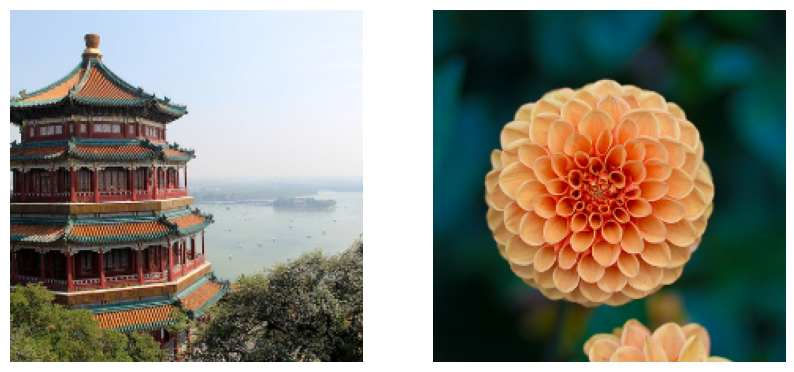

In [36]:
plt.figure(figsize=(10, 6))
for idx in (0, 1):
    plt.subplot(1, 2, idx + 1)
    plt.imshow(images_resized[idx] / 255)
    plt.axis("off")

plt.show()

## Modelos preentrenados para el aprendizaje por transferencia

* Se tiene casos en los que se tiene un dataset con pocos datos.
* Se podría usar un modelo preentrenado modificándolo.
* La idea es usar parte de las capas del modelo preentrenado.
* Se crea  un nuevo modelo agregando capas específicas del nuevo modelo más las capas del modelo preentrenado.
* Se entrena el nuevo modelo con los pocos datos del dataset nuevo.


In [37]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.ZQLJKQ_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


* Número de elementos en el conjunto de datos

In [38]:
dataset_size

3670

* El conjunto de datos tiene cinco categorías (clases) de flores

In [39]:
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

* Número de clases

In [40]:
n_classes

5

* Se particiona el conjunto en:
1. 10% para validación.
2. 15% para testing.
3. 75% para entrenamiento.

In [41]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

* Se presenta una muesta del conjunto de datos.

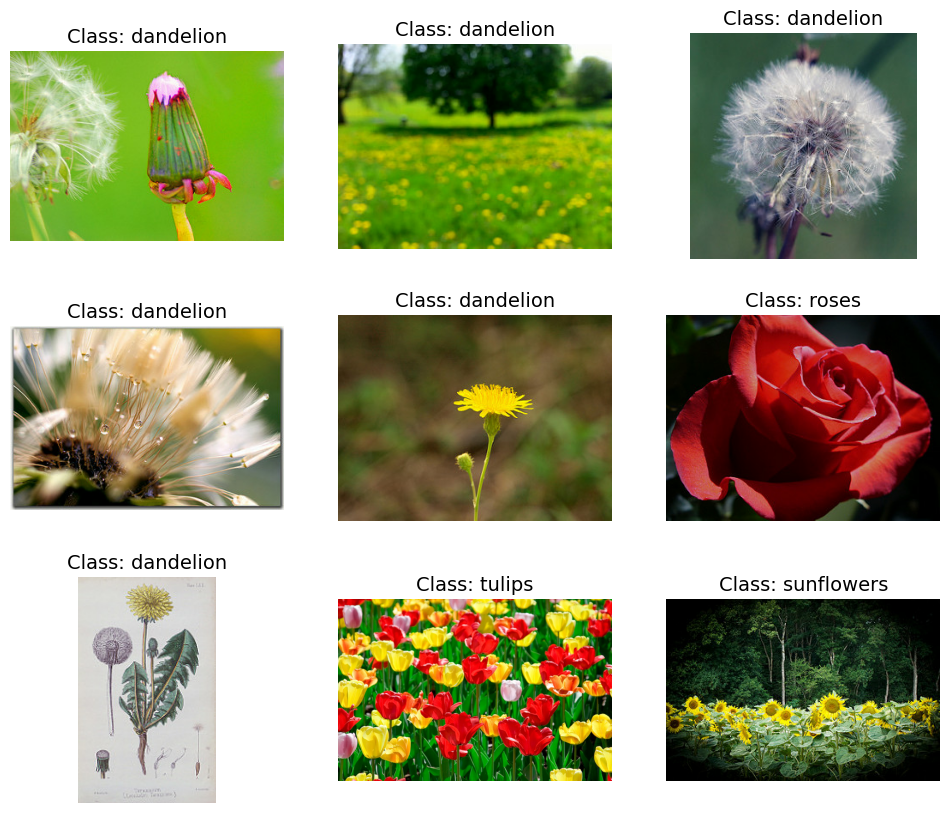

In [42]:
plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

* Se usa el modelo Xception.
* Se preprocesa el dataset de flores para que tenga el mismo tamaño de las imaǵenes del modelo Xception preentrenado.
* El valor de los píxeles van a estar entre -1 y 1.

In [43]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

* Se presenta una muestra de 9 imágenes del dataset preprocesado.
* Las imágenes son 224 x 224 píxeles.

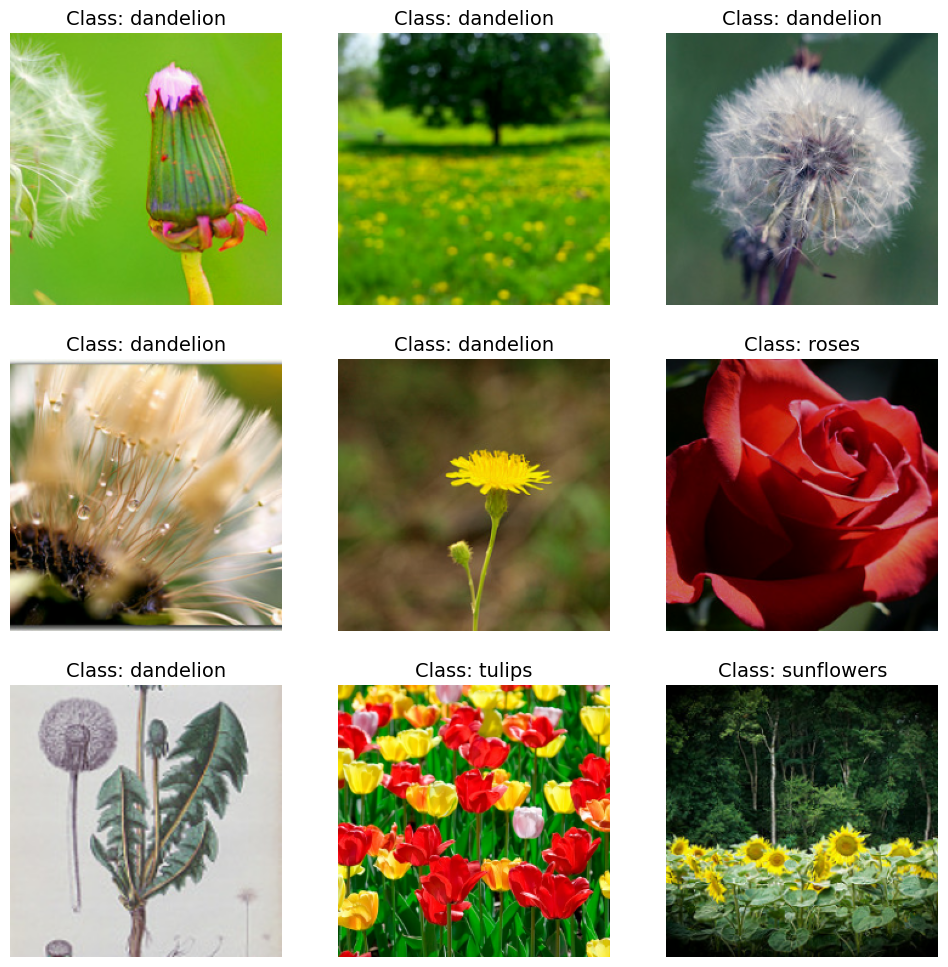

In [44]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

* Como es un conjunto de datos pequeño, se aumenta modificando las imágenes originales.

In [45]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

* Se usa como base el modelo de Xception preentrenado con el dataset Imagenet.
* Al modelo de Xception se le eliminan las capa del tope
* El tope incluye la capa de pooling (agrupamiento) y la capa de salida
* El nuevo modelo esta compuesto por:
1. El modelo de Xception sin las capas tope
2. Luego se agrega una capa de pooling
3. Se agrega una capa de salida con función softmax para clasificar las 5 clases de imágens de flores.

In [46]:
tf.random.set_seed(42)  # ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


* En un primer término en el entrenamiento no modificamos los pesos preentrenados.
* Esto se hace para entrenar las capas agregadas más rápidamente.

In [47]:
for layer in base_model.layers:
    layer.trainable = False

* Se compila el modelo creado y se entrena
* Se recomiendo usar GPU

In [48]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 56s 358ms/step - accuracy: 0.7998 - loss: 0.8239 - val_accuracy: 0.8385 - val_loss: 0.6803
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 164ms/step - accuracy: 0.9128 - loss: 0.3206 - val_accuracy: 0.8639 - val_loss: 0.5690
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 166ms/step - accuracy: 0.9357 - loss: 0.1939 - val_accuracy: 0.8675 - val_loss: 0.6421


* Se muestran las capas del modelo creado

In [49]:
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_1          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

* Los pesos del tope tienen valores aceptables.
* Luego se puede entrenar el modelo completo.

In [50]:
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 58s 422ms/step - accuracy: 0.9106 - loss: 0.2828 - val_accuracy: 0.8802 - val_loss: 0.5777
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.9818 - loss: 0.0563 - val_accuracy: 0.8984 - val_loss: 0.3566
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 337ms/step - accuracy: 0.9945 - loss: 0.0208 - val_accuracy: 0.9038 - val_loss: 0.2872
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 343ms/step - accuracy: 0.9967 - loss: 0.0112 - val_accuracy: 0.9093 - val_loss: 0.2857
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 347ms/step - accuracy: 0.9975 - loss: 0.0074 - val_accuracy: 0.9201 - val_loss: 0.2821
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 352ms/step - accuracy: 0.9989 - loss: 0.0043 - val_accuracy: 0.9147 - val_loss: 0.3050
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 353ms/step - accuracy: 0.9982 - loss: 0.0065 - val_accuracy: 0.9093 - val_loss: 0.3320
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 350ms/step - accuracy: 0.9996 - loss: 0.0018 - val_accu

## Clasificación y Localización

* Se quiere localizar un objeto dentro de una imagen

In [51]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)
loc_output = tf.keras.layers.Dense(4)(avg)
model = tf.keras.Model(inputs=base_model.input,
                       outputs=[class_output, loc_output])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)  # added this line
model.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2],  # depends on what you care most about
              optimizer=optimizer, metrics=["accuracy", "mse"])

* Métrica Intersección sobre Unión IoU

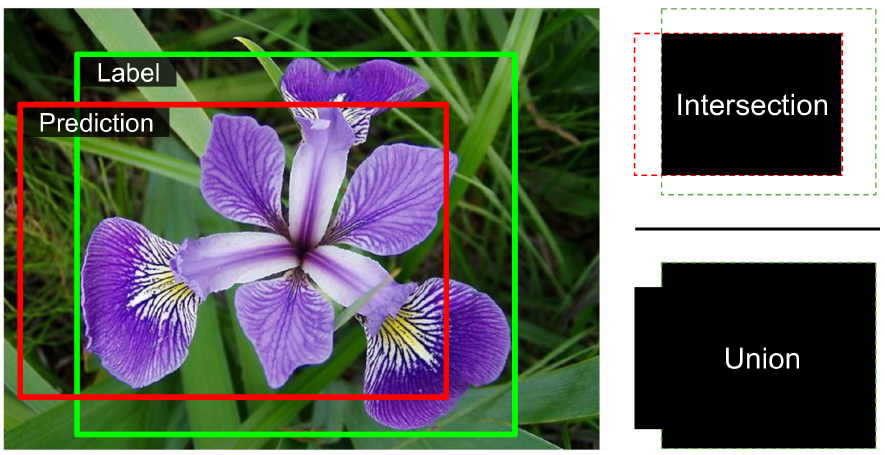

* Se coloca el objeto a buscar en una caja

In [52]:
def add_random_bounding_boxes(images, labels):
    fake_bboxes = tf.random.uniform([tf.shape(images)[0], 4])
    return images, (labels, fake_bboxes)

fake_train_set = train_set.take(5).repeat(2).map(add_random_bounding_boxes)
model.fit(fake_train_set, epochs=2)

Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 517ms/step - dense_1_accuracy: 0.4094 - dense_1_loss: 1.4728 - dense_2_loss: 0.2924 - dense_2_mse: 0.2924 - loss: 1.2367
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 559ms/step - dense_1_accuracy: 0.7063 - dense_1_loss: 0.9883 - dense_2_loss: 0.2088 - dense_2_mse: 0.2088 - loss: 0.8324
